# Re-analysis of the MIBI CRC TMA data – Glycolysis and proliferation

Next: 
* Find cell table including proliferation, glycolysis markers and lineage markers -> Re-export from (1)
* Run multiview MISTy
* Look at association between Ki67 and macrophage markers in cancer samples
* Compare to background in healthy sample

In [1]:
library(mistyR)
library(tidyverse)
library(future)
library(proxy)
library(withr)
library(igraph)
library(ggplot2)

mistyR is able to run computationally intensive functions
  in parallel. Please consider specifying a future::plan(). For example by running
  future::plan(future::multisession) before calling mistyR functions.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘proxy’


The following objects are masked from ‘package:stats’:

    as.dist, dist


The following object is masked from ‘package:base’:

    as.matrix



Attaching package: ‘igraph’


The following objects are masked from ‘package:future’:

 

In [4]:
# Load your transformed cell table
cells = read_csv("./data/cell_profiles_with_types_and_clinical_info.csv")
head(cells)

Rows: 564276 Columns: 84
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (31): fov, annotation_t, annotation_scyan, consensus, annotation_consens...
dbl (51): CA9, nuclei, CD98, CytC, MSH2, MCT1, PDL1, PD1, ASCT2, LDH, STING1...
lgl  (2): Grade raw, pM group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


CA9,nuclei,CD98,CytC,MSH2,MCT1,PDL1,PD1,ASCT2,LDH,⋯,CD68,CD8,CD3e,MPO,CD20,HLADRa,CD14,CD45,PanCK,FoxP3
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.02128943,0.04614832,0.006392956,0.01571343,0.02473370,0.0001934555,0.009022579,0.004549611,0.04586374,0.013713424,⋯,1.466995e-03,0.0042829029,0.0074069532,0.0009535642,0.0021309408,0.037933880,0.085220196,0.007160618,0.13530531,0.023452892
0.01457781,0.03423819,0.008830998,0.10651270,0.06347377,0.0027742222,0.004172783,0.000000000,0.02873399,0.002855385,⋯,8.613262e-04,0.0000000000,0.0002477325,0.0013890444,0.0025270705,0.014583903,0.049939281,0.010767323,0.02350778,0.001185208
0.11329879,0.06419776,0.034138213,0.01142891,0.06656348,0.0015064266,0.009497505,0.000000000,0.02825994,0.013808767,⋯,2.330135e-05,0.0000000000,0.0151856856,0.0002203887,0.0000000000,0.040933724,0.032443213,0.006273398,0.02681020,0.000000000
0.12827739,0.09715288,0.040913454,0.03036816,0.01601639,0.0052802216,0.022267382,0.028413114,0.03409141,0.032230635,⋯,4.780378e-04,0.0000000000,0.0038403347,0.0001791699,0.0003469854,0.007038222,0.031057618,0.006579229,0.06933960,0.001457594
0.10768224,0.05414692,0.070130227,0.09855133,0.08103716,0.0209243360,0.004453675,0.022994452,0.11757625,0.035626791,⋯,5.659217e-03,0.0002388359,0.0133130447,0.0007415019,0.0004687107,0.017894487,0.034549653,0.002349149,0.12780672,0.001234451
0.10965646,0.01982199,0.026331486,0.06694059,0.02464267,0.0497367896,0.001608107,0.027431549,0.19049839,0.011646049,⋯,2.177312e-04,0.0000000000,0.0146461835,0.0001958524,0.0000000000,0.025598212,0.005974006,0.009822941,0.12672245,0.000000000


In [5]:
names(cells)

[1] "CA9"                                   
 [2] "nuclei"                                
 [3] "CD98"                                  
 [4] "CytC"                                  
 [5] "MSH2"                                  
 [6] "MCT1"                                  
 [7] "PDL1"                                  
 [8] "PD1"                                   
 [9] "ASCT2"                                 
[10] "LDH"                                   
[11] "STING1"                                
[12] "DCN"                                   
[13] "GS"                                    
[14] "GLS"                                   
[15] "ATP5A"                                 
[16] "CS"                                    
[17] "PKM2"                                  
[18] "GLUT1"                                 
[19] "MSH6"                                  
[20] "ARG1"                                  
[21] "CPT1A"                                 
[22] "Vimentin"                              
[23] "Ki67"                                  
[24] "membrane"                              
[25] "centroid-0"                            
[26] "centroid-1"                            
[27] "eccentricity"                          
[28] "perimeter"                             
[29] "convex_area"                           
[30] "area"                                  
[31] "axis_major_length"                     
[32] "axis_minor_length"                     
[33] "label"                                 
[34] "fov"                                   
[35] "annotation_t"                          
[36] "annotation_scyan"                      
[37] "consensus"                             
[38] "annotation_consensus"                  
[39] "TMA name"                              
[40] "TMA sector"                            
[41] "Tumorlokalisation COL10"               
[42] "Tumorlokalisation alle RED"            
[43] "Tumor Seite alle"                      
[44] "Tumortyp"                              
[45] "pT raw"                                
[46] "pN raw"                                
[47] "Grade raw"                             
[48] "pT group"                              
[49] "pN group"                              
[50] "pM group"                              
[51] "Tumordurchmesser (mm)"                 
[52] "Muzinöse Tumorkomponente"              
[53] "Infiltrationstyp"                      
[54] "Tumorbudding"                          
[55] "Peritumorale lymphozytäre Infiltration"
[56] "Angioinvasion V RED"                   
[57] "Lymphbahninvasion L"                   
[58] "MSI im Befund"                         
[59] "MSI gesamt RED"                        
[60] "RAS Mutation RED"                      
[61] "RAS Mutation RED 2"                    
[62] "BRAF Mutation RED"                     
[63] "HER2 Amplifikation"                    
[64] "Age"                                   
[65] "Sex"                                   
[66] "MIBI"                                  
[67] "Tumor Size Group"                      
[68] "Age Group"                             
[69] "Stage"                                 
[70] "SMA"                                   
[71] "CD4"                                   
[72] "CD31"                                  
[73] "CD7"                                   
[74] "CD163"                                 
[75] "CD68"                                  
[76] "CD8"                                   
[77] "CD3e"                                  
[78] "MPO"                                   
[79] "CD20"                                  
[80] "HLADRa"                                
[81] "CD14"                                  
[82] "CD45"                                  
[83] "PanCK"                                 
[84] "FoxP3"

In [6]:
# Exclude low epithelial abundance samples and SCT samples (start with "E1" or "E2")

# See StageXGB.ipynb
excluded_fovs = c('A2n','A3r','A4i','A5c','A7c','A7m','A8f','A9k','A9p','B1q','B2l',
                  'B2n','B3o','B4a','B4n','B5h','B5i','B5p','B6l','B7g','B7k','B7q',
                  'B8c','B9r','C2e','C9a','C9d','C9e','C9i','D1c','D1g','D2c','D3m',
                  'D4e','D6e','D6i','D7b','D8m','D9g','D9l')

cells <- cells %>% 
    filter(!(fov %in% excluded_fovs)) %>%
    filter(!grepl("^E[1-2]", fov))

In [7]:
paraview_l <- 120 # Distance in pixels up to which an effect will be considered in the paraview
juxtaview_l <- 40 # Distance in pixels up to which a cell is considered a direct neighbor
panel = c('PanCK', 'CD163', 'CD68', 'MCT1', 'LDH', 'GLUT1', 'Ki67')  # Markers to be used for the analysis
outputfile = "misty_colorectal_macro_prolif_multiview.sqm"

# Expected data is a list of tibbles with each one containing the marker expressions (columns) per cell (rows) for a fov
markers <- cells %>% group_by(fov) %>% select(all_of(panel)) %>% group_split(.keep = FALSE)

Adding missing grouping variables: `fov`


In [8]:
# Coordinates of each cell
positions <- cells %>% group_by(fov) %>% select(c("centroid-0", "centroid-1")) %>% group_split(.keep = FALSE)

Adding missing grouping variables: `fov`


In [9]:
# Extract the names of the FOVs in the same order as the markers and positions tables
fov_names <- cells %>% group_by(fov) %>% summarise(fov = first(fov)) %>% pull(fov)

In [10]:
outputs <- seq_along(markers) %>% walk(
    function(i) {
    misty.views <- create_initial_view(markers[[i]]) %>%
        add_paraview(positions[[i]], paraview_l,
            family = "gaussian", cached = TRUE,
            prefix = "p.", zoi = juxtaview_l,
        ) %>%
        add_juxtaview(positions[[i]], juxtaview_l,
            prefix = "l."
        )

    folders <- run_misty(misty.views,
        sample.id = fov_names[i],
        results.db = outputfile,
        bypass.intra = FALSE,
        cv.strict = TRUE,
        sqlite_timeout = 10000
    )})


Generating paraview


Attaching package: ‘distances’


The following object is masked from ‘package:igraph’:

    distances



Computing triangulation


Generating juxtaview


Training models

Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target PanCK”
Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target CD163”
Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target CD68”
Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target MCT1”
Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target Ki67”

Generating paraview


Computing triangulation


Generating juxtaview


Training models

Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with 0 for target CD68”
Warning message in ...furrr_fn(...):
“Negative performance detected and replaced with

In [11]:
library(DBI)
library(RSQLite)
library(dplyr)

In [12]:
describe_sample_type <- function(dbfile, is_healthy = TRUE) {
  # Get all samples
  dbcon <- dbConnect(RSQLite::SQLite(), dbfile)
  samples <- dbGetQuery(dbcon, "SELECT DISTINCT sample FROM contributions") %>% 
    unlist()
  dbDisconnect(dbcon)
  
  # Create pattern based on sample type
  pattern <- if(is_healthy) {
    # Match E3 or E4 prefix
    paste0("(", paste0(
      grep("^(E3|E4)", samples, value = TRUE),
      collapse = "|"
    ), ")")
  } else {
    # Match anything not starting with E3 or E4
    paste0("(", paste0(
      grep("^(?!(E3|E4))", samples, value = TRUE, perl = TRUE),
      collapse = "|"
    ), ")")
  }
  
  # Collect filtered results
  collect_results(dbfile, pattern)
}

In [16]:
tumor_results <- describe_sample_type(outputfile, is_healthy = FALSE)








Aggregating



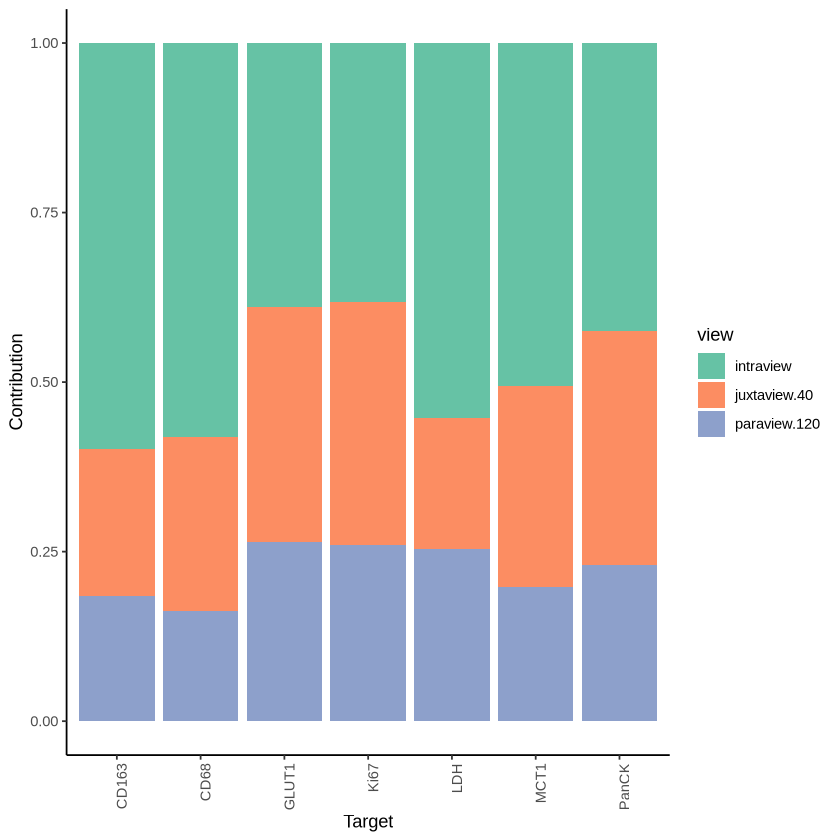

In [18]:
plot_view_contributions(tumor_results)


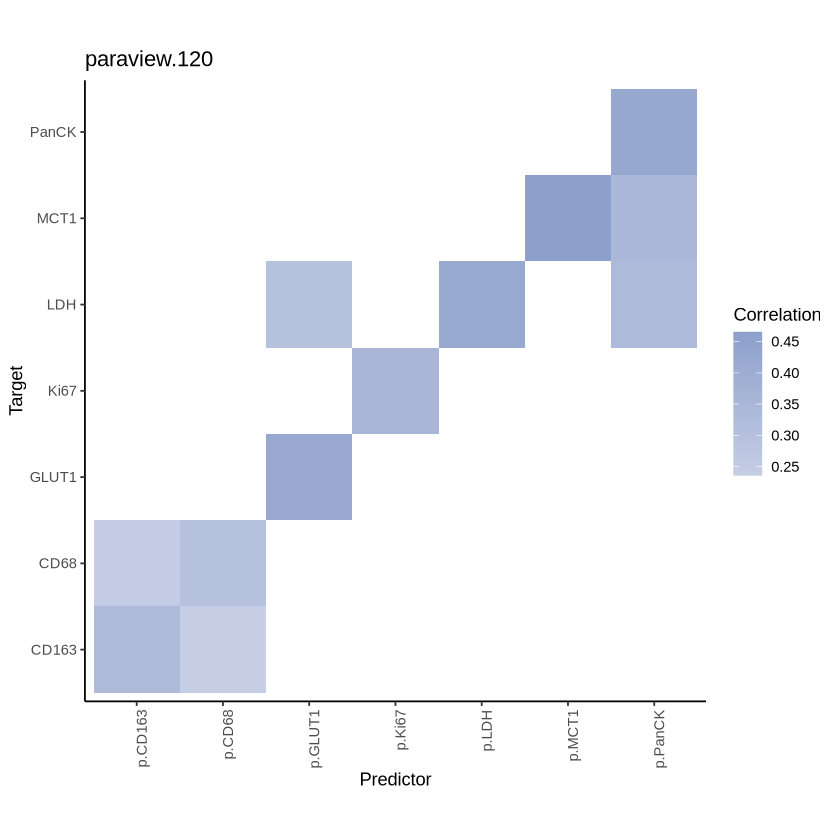

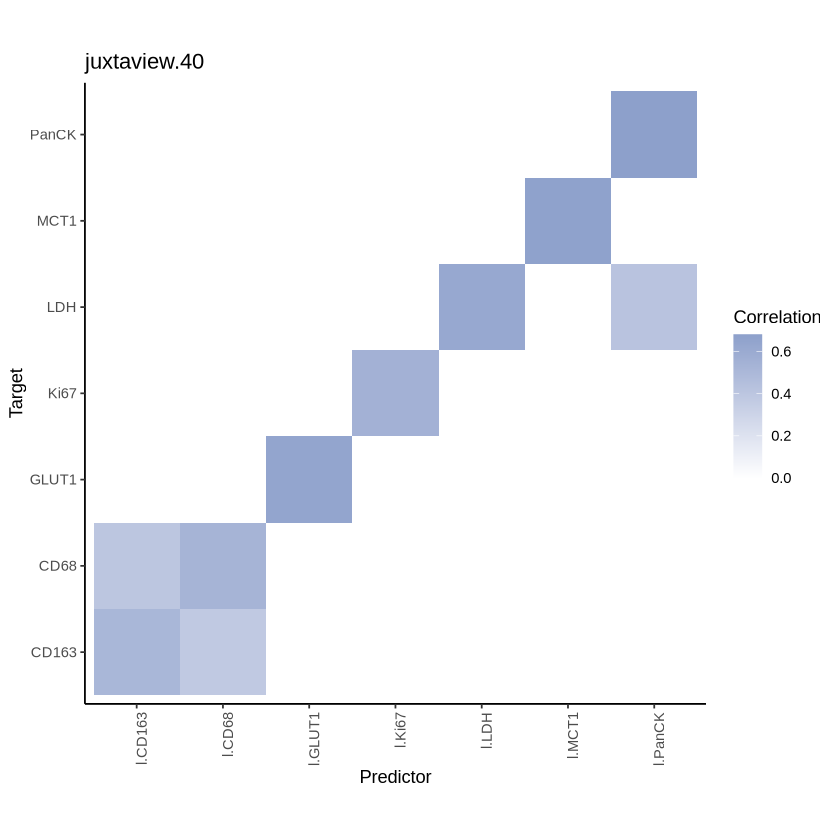

In [25]:
plot_interaction_heatmap(tumor_results, "paraview.120", clean = TRUE, correlation = TRUE,
                         trim = 1, cutoff = 0.05)
plot_interaction_heatmap(tumor_results, "juxtaview.40", clean = TRUE, correlation = TRUE,
                         trim = 1, cutoff = 0.05)

No clear pattern linking macrophage lineage markers to other markers in surrounding cells.  
Now directly looking at these factors and how it changes across stages.

In [56]:
fov_features <- extract_signature(tumor_results, type = "i", intersect.targets = FALSE, trim = 1)
print(dim(fov_features))
fov_features[is.na(fov_features)] <- floor(min(fov_features %>% select(-sample), na.rm = TRUE))
fov_features <- fov_features %>% mutate(across(!sample, ~ ifelse(.x <= 0.25, 0, .x)))
# Drop columns with all zeros
keep <- names(which(fov_features %>% select(-sample, -contains("intra_")) %>% colSums() > 0))
fov_features <- fov_features %>%
    select(sample, all_of(keep))
print(dim(fov_features))
print(str_c('Local proliferation from CD68: ', 'juxtaview.40_l.Ki67_CD68' %in% names(fov_features)))
print(str_c('Local proliferation from CD163: ', 'intraview_CD163_Ki67' %in% names(fov_features)))

[1] 418 148
[1] 418 141
[1] "Local proliferation from CD68: TRUE"
[1] "Local proliferation from CD163: TRUE"


In [71]:
# Select the pattern of interest
imp <- fov_features %>%
    select(c("sample", "juxtaview.40_l.Ki67_CD68")) %>%
    rename(Importance = juxtaview.40_l.Ki67_CD68) %>%
    arrange(desc(Importance))
# Build sample -> stage lookup from the cell table
stage_lookup <- cells %>%
    distinct(fov, `pT group`) %>%
    rename(sample = fov, stage = `pT group`)
# Add stage to the importance table
imp <- imp %>%
    left_join(stage_lookup, by = "sample")
imp[imp$Importance > 0,]

sample,Importance,stage
<chr>,<dbl>,<chr>
B1p,1.6067618,pT4
B8e,0.9733295,pT3
D1k,0.5725898,pT3
C5c,0.5602315,pT3
D1i,0.3713497,pT2
A6g,0.3515327,pT4
B9q,0.3380341,pT3
A9c,0.2894963,pT4
C2b,0.2744826,pT3


In [72]:
# Select the pattern of interest
imp <- fov_features %>%
    select(c("sample", "juxtaview.40_l.Ki67_CD163")) %>%
    rename(Importance = juxtaview.40_l.Ki67_CD163) %>%
    arrange(desc(Importance))
# Add stage to the importance table
imp <- imp %>%
    left_join(stage_lookup, by = "sample")
imp[imp$Importance > 0,]

sample,Importance,stage
<chr>,<dbl>,<chr>
D4m,1.4019499,pT3
C2m,1.2477986,pT3
C5d,1.1539121,pT2
D4l,0.9405798,pT3
A6m,0.7676986,pT3
C7i,0.4839130,pT3
B8g,0.4367577,pT2
B8h,0.3330575,pT4
B4g,0.2970803,pT2


See if it's any different in the healthy samples.

In [73]:
healthy_results <- describe_sample_type(outputfile, is_healthy = TRUE)








Aggregating



In [ ]:
fov_features <- extract_signature(healthy_results, type = "i", intersect.targets = FALSE, trim = 1)
print(dim(fov_features))
fov_features[is.na(fov_features)] <- floor(min(fov_features %>% select(-sample), na.rm = TRUE))
# fov_features <- fov_features %>% mutate(across(!sample, ~ ifelse(.x <= 10, 0, .x)))
# Drop columns with all zeros
keep <- names(which(fov_features %>% select(-sample, -contains("intra_")) %>% colSums() > 0))
fov_features <- fov_features %>%
    select(sample, all_of(keep))
print(dim(fov_features))
print(str_c('Local proliferation from CD68: ', 'juxtaview.40_l.Ki67_CD68' %in% names(fov_features)))
print(str_c('Local proliferation from CD163: ', 'intraview_CD163_Ki67' %in% names(fov_features)))
# All zeroes: no interaction detected for any of the 5 samples

[1]   5 148
[1]  5 59
[1] "Local proliferation from CD68: FALSE"
[1] "Local proliferation from CD163: FALSE"
